In [11]:
import pandas as pd
import json
import networkx as nx
import matplotlib.pyplot as plt

In [3]:
with open('synthetic_security_data.json') as file:
    json_data = json.load(file)

events = pd.DataFrame(json_data['events'])
entities = pd.DataFrame(json_data['entities'])
relationships = pd.DataFrame(json_data['relationships'])

attack_scenarios = pd.DataFrame(json_data['ground_truth']['attack_scenarios'])

In [4]:
events

,id,type,timestamp,severity,alert_style,alert_message,description
0,EVT-0001,Authentication,2025-06-03T03:58:41.800244,7,raw_telemetry,Off-hours authentication by Robert Miller on A...,Authentication event detected
1,EVT-0002,Privilege Operation,2025-06-03T05:58:41.800244,7,raw_telemetry,Admin rights granted to Robert Miller on APP-284,Privilege Operation event detected
2,EVT-0003,Defense Evasion,2025-06-03T07:58:41.800244,6,behavioral,Timestomping detected on unknown on APP-284,Defense Evasion event detected
3,EVT-0004,Data Access,2025-06-03T09:58:41.800244,6,raw_telemetry,Bulk file access by Robert Miller on APP-284: ...,Data Access event detected
4,EVT-0005,Exfiltration,2025-06-03T11:58:41.800244,6,rules_based,Unusual DNS tunneling from APP-284 to unknown,Exfiltration event detected
...,...,...,...,...,...,...,...
993,EVT-0994,Defense Evasion,2025-06-05T16:48:53.756719,7,behavioral,Log clearing detected on APP-809 by Ella Thomas,Defense Evasion event detected
994,EVT-0995,Defense Evasion,2025-06-05T17:48:57.062981,6,rules_based,Obfuscated script execution by Ella Thomas on ...,Defense Evasion event detected
995,EVT-0996,Exfiltration,2025-06-05T18:49:00.369243,7,behavioral,Encrypted archive fbcpb95.vbs sent externally ...,Exfiltration event detected
996,EVT-0997,Privilege Operation,2025-06-05T19:49:03.675505,6,raw_telemetry,Admin rights granted to Ella Thomas on APP-809,Privilege Operation event detected


In [5]:
entities

,id,type,name
0,ENT-0001,User,Robert Miller
1,ENT-0002,Host,APP-284
2,ENT-0003,Process,msiexec.exe
3,ENT-0004,NetworkConnection,192.168.36.218
4,ENT-0005,Process,code.exe
...,...,...,...
2329,ENT-2330,File,fbcpb95.vbs
2330,ENT-2331,Domain,ikmgac.net
2331,ENT-2332,File,iohob66.pdf
2332,ENT-2333,Database,HRDatabase


In [19]:
relationships

,id,source,target,type,weight
0,REL-0001,EVT-0001,ENT-0001,related_to,0.898
1,REL-0002,EVT-0001,ENT-0002,related_to,0.803
2,REL-0003,EVT-0001,ENT-0003,related_to,0.787
3,REL-0004,EVT-0001,ENT-0004,related_to,0.855
4,REL-0005,EVT-0002,ENT-0001,related_to,0.913
...,...,...,...,...,...
3967,REL-3968,EVT-0997,ENT-2332,related_to,0.714
3968,REL-3969,EVT-0998,ENT-2319,related_to,0.615
3969,REL-3970,EVT-0998,ENT-2320,related_to,0.656
3970,REL-3971,EVT-0998,ENT-2333,related_to,0.759


In [20]:
attack_scenarios

,description,event_ids,entity_ids
0,Attack Scenario: Supply Chain Attack,"[EVT-0001, EVT-0002, EVT-0003, EVT-0004, EVT-0...","[ENT-0001, ENT-0002, ENT-0003, ENT-0004, ENT-0..."
1,Attack Scenario: Supply Chain Attack,"[EVT-0006, EVT-0007, EVT-0008, EVT-0009, EVT-0...","[ENT-0010, ENT-0011, ENT-0012, ENT-0013, ENT-0..."
2,Attack Scenario: Supply Chain Attack,"[EVT-0011, EVT-0012, EVT-0013, EVT-0014, EVT-0...","[ENT-0023, ENT-0024, ENT-0025, ENT-0026, ENT-0..."
3,Attack Scenario: Ransomware,"[EVT-0017, EVT-0018, EVT-0019, EVT-0020]","[ENT-0032, ENT-0033, ENT-0034, ENT-0035, ENT-0..."
4,Attack Scenario: Ransomware,"[EVT-0021, EVT-0022, EVT-0023, EVT-0024, EVT-0...","[ENT-0043, ENT-0044, ENT-0045, ENT-0046, ENT-0..."
5,Attack Scenario: Ransomware,"[EVT-0026, EVT-0027, EVT-0028, EVT-0029]","[ENT-0056, ENT-0057, ENT-0058, ENT-0059, ENT-0..."


In [7]:
'''
Sanity Check
====================================================================================
The event_ids that appear in the ground_truth.attack_scenarios array are precisely
those that are listed in ground_truth.true_positive_events.
'''

e = [event for i in range(len(attack_scenarios)) for event in attack_scenarios['event_ids'][i]]
print(set(e) == set(json_data['ground_truth']['true_positive_events'])) # should print true

'''
Likewise, the entity_ids that appear in the ground_truth.attack_scenarios array are precisely
those that are listed in ground_truth.true_positive_entities.
'''

e = [entity for i in range(len(attack_scenarios)) for entity in attack_scenarios['entity_ids'][i]]
print(set(e) == set(json_data['ground_truth']['true_positive_entities'])) # should print true

True
True


In [8]:
def create_bipartite_graph(part1, part2, edges) -> nx.Graph:
    """Load json file and return a bipartite weighted graph.

    Nodes are the `id` values from `events` and `entities`.
    Edges are created from `relationships` with the edge attribute `weight` set
    from the relationship's `weight` field. Each node gets attributes:
    - `kind`: either 'event' or 'entity'
    - `bipartite`: 0 for events, 1 for entities
    """
    G = nx.Graph()

    part1_ids = part1["id"]
    part2_ids = part2["id"]

    for nid in part1_ids:
        G.add_node(nid, bipartite=0)
    for nid in part2_ids:
        G.add_node(nid, bipartite=1)

    for i, e in edges.iterrows():
        src = e["source"]
        tgt = e["target"]
        weight = e["weight"]
        rtype = e["type"]

        if src is None or tgt is None:
            continue

        # Ensure nodes exist in graph (in case relationships reference missing ids)
        if src not in G:
            print("source node not in G")
            G.add_node(src, kind=("event" if src in event_ids else "entity"), bipartite=(0 if src in event_ids else 1))

        if tgt not in G:
            print("target node not in G")
            G.add_node(tgt, kind=("event" if tgt in event_ids else "entity"), bipartite=(0 if tgt in event_ids else 1))

        G.add_edge(src, tgt, weight=weight, type=rtype)

    return G

def connected_components_sorted(G: nx.Graph):
    """Return connected components sorted by size (descending)."""
    comps = list(nx.connected_components(G))
    comps.sort(key=len, reverse=True)
    return comps

Loaded graph: 3332 nodes, 3972 edges
Connected components: 179
asdfsadf True


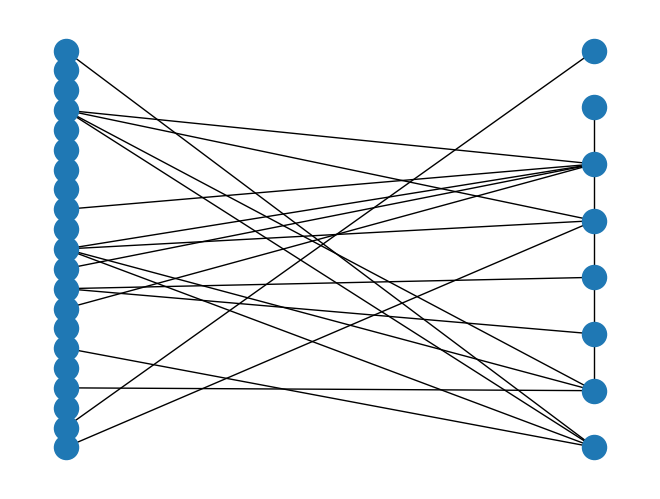

In [29]:
G = create_bipartite_graph(events, entities, relationships)
print(f"Loaded graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

from networkx.algorithms import bipartite

#print("Is bipartite ", bipartite.is_bipartite(G))
	# show a few sample edges
#for u, v, d in list(G.edges(data=True))[:1000]:
#	print(u, "-", v, ":", d)

comps = connected_components_sorted(G)
print(f"Connected components: {len(comps)}")
# print sizes of the 5 largest components
for i, comp in enumerate(comps[1:2], start=1):
    #print(f"Component {i}: size={len(comp)}")
    plt.figure(i)
    print("asdfsadf", bipartite.is_bipartite(nx.induced_subgraph(G, comp)))
    nx.draw_bipartite(nx.induced_subgraph(G, comp))

plt.show()
#This is a test change.